<a href="https://colab.research.google.com/github/agief-G1A024037/G1A024037_Agief-Vemas-a-NaiveBayes-/blob/main/Bagian2(No3).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. HUBUNGKAN DRIVE

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
save_folder = '/content/drive/MyDrive/Tugas2No3/KNN_Simulation'
os.makedirs(save_folder, exist_ok=True)

print(f'✅ Google Drive terhubung!')
print(f'📁 Folder: {save_folder}')

Mounted at /content/drive
✅ Google Drive terhubung!
📁 Folder: /content/drive/MyDrive/Tugas2No3/KNN_Simulation


2. IMPORT LIBRARY

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree

print('✅ Semua library berhasil diimport!')

✅ Semua library berhasil diimport!


3. BUAT DATASET

In [ ]:
np.random.seed(42)

cats_size   = np.random.normal(3.5, 0.8, 30)
cats_energy = np.random.normal(5.0, 1.2, 30)
cats_label  = np.zeros(30, dtype=int)

dogs_size   = np.random.normal(7.0, 1.5, 30)
dogs_energy = np.random.normal(7.5, 1.0, 30)
dogs_label  = np.ones(30, dtype=int)

unusual_size   = np.array([2.5])
unusual_energy = np.array([4.5])
unusual_label  = np.array([1])

X = np.column_stack([
    np.concatenate([cats_size, dogs_size, unusual_size]),
    np.concatenate([cats_energy, dogs_energy, unusual_energy])
])
y = np.concatenate([cats_label, dogs_label, unusual_label])
X = np.clip(X, 1, 10)

label_names  = {0: 'Kucing', 1: 'Anjing'}
unusual_flag = ['Ya' if i == len(y)-1 else 'Tidak' for i in range(len(y))]

print(f'✅ Dataset berhasil dibuat!')
print(f'   Total : {len(y)} sampel')
print(f'   Kucing: {sum(y==0)} sampel')
print(f'   Anjing: {sum(y==1)} sampel (termasuk 1 unusual token)')

✅ Dataset berhasil dibuat!
   Total : 61 sampel
   Kucing: 30 sampel
   Anjing: 31 sampel (termasuk 1 unusual token)


4. SIMPAN DATASET KE EXCEL

In [ ]:
df_dataset = pd.DataFrame({
    'No'             : range(1, len(y)+1),
    'Ukuran_Tubuh'   : np.round(X[:,0], 3),
    'Tingkat_Energi' : np.round(X[:,1], 3),
    'Label_Angka'    : y,
    'Label_Nama'     : [label_names[i] for i in y],
    'Unusual_Token'  : unusual_flag
})

excel_path = f'{save_folder}/KNN_Dataset.xlsx'
with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    df_dataset.to_excel(writer, sheet_name='Dataset', index=False)

print(f'✅ Dataset Excel disimpan!')
print(f'📄 {excel_path}')
print(df_dataset.head(10))

✅ Dataset Excel disimpan!
📄 /content/drive/MyDrive/Tugas2No3/KNN_Simulation/KNN_Dataset.xlsx
   No  Ukuran_Tubuh  Tingkat_Energi  Label_Angka Label_Nama Unusual_Token
0   1         3.897           4.278            0     Kucing         Tidak
1   2         3.389           7.223            0     Kucing         Tidak
2   3         4.018           4.984            0     Kucing         Tidak
3   4         4.718           3.731            0     Kucing         Tidak
4   5         3.313           5.987            0     Kucing         Tidak
5   6         3.313           3.535            0     Kucing         Tidak
6   7         4.763           5.251            0     Kucing         Tidak
7   8         4.114           2.648            0     Kucing         Tidak
8   9         3.124           3.406            0     Kucing         Tidak
9  10         3.934           5.236            0     Kucing         Tidak


5. ANALISIS MEMORI

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=3)
dt_model  = DecisionTreeClassifier(max_depth=4, random_state=42)
knn_model.fit(X, y)
dt_model.fit(X, y)

knn_mem = X.nbytes + y.nbytes
dt_mem  = dt_model.tree_.node_count * 5 * 8

print('='*60)
print('  BAGIAN 2 NO.3 — ANALISIS MEMORI SAAT TESTING')
print('='*60)
print(f'\n🔵 KNN (Non-Parametric Learner):')
print(f'   Yang disimpan     : SELURUH data training')
print(f'   Jumlah data       : {len(y)} sampel')
print(f'   Ukuran memori     : {knn_mem} bytes ({knn_mem/1024:.2f} KB)')
print(f'   Komputasi/prediksi: hitung jarak ke SEMUA {len(y)} data')
print(f'   Skala memori      : LINEAR')
print(f'\n🟢 Decision Tree (Parametric Learner):')
print(f'   Yang disimpan     : hanya parameter pohon')
print(f'   Jumlah node       : {dt_model.tree_.node_count} node')
print(f'   Ukuran memori     : ~{dt_mem} bytes ({dt_mem/1024:.2f} KB)')
print(f'   Komputasi/prediksi: ikuti cabang root → leaf')
print(f'   Skala memori      : LOGARITMIK (hampir konstan)')
print(f'\n📈 KNN butuh ~{knn_mem/dt_mem:.1f}x lebih banyak memori')
print(f'\n💡 KESIMPULAN:')
print(f'   KNN = Non-Parametric → data training ADALAH modelnya.')
print(f'   Decision Tree = Parametric → cukup simpan parameter pohon.')

  BAGIAN 2 NO.3 — ANALISIS MEMORI SAAT TESTING

🔵 KNN (Non-Parametric Learner):
   Yang disimpan     : SELURUH data training
   Jumlah data       : 61 sampel
   Ukuran memori     : 1464 bytes (1.43 KB)
   Komputasi/prediksi: hitung jarak ke SEMUA 61 data
   Skala memori      : LINEAR

🟢 Decision Tree (Parametric Learner):
   Yang disimpan     : hanya parameter pohon
   Jumlah node       : 9 node
   Ukuran memori     : ~360 bytes (0.35 KB)
   Komputasi/prediksi: ikuti cabang root → leaf
   Skala memori      : LOGARITMIK (hampir konstan)

📈 KNN butuh ~4.1x lebih banyak memori

💡 KESIMPULAN:
   KNN = Non-Parametric → data training ADALAH modelnya.
   Decision Tree = Parametric → cukup simpan parameter pohon.


6. GRAFIK SKALABILITAS MEMORI

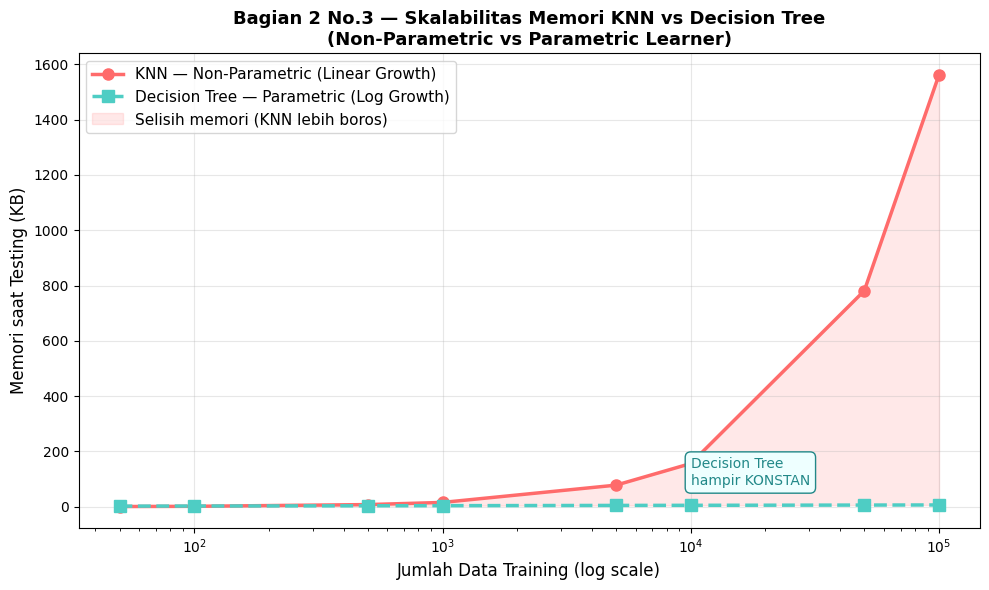

✅ Grafik disimpan!


In [ ]:
sizes        = [50, 100, 500, 1000, 5000, 10000, 50000, 100000]
knn_mem_list = [n * 2 * 8 for n in sizes]
dt_mem_list  = [int(np.log2(n) * 5 * 8 * 10) for n in sizes]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(sizes, [m/1024 for m in knn_mem_list],
        'o-', color='#FF6B6B', linewidth=2.5, markersize=8,
        label='KNN — Non-Parametric (Linear Growth)')
ax.plot(sizes, [m/1024 for m in dt_mem_list],
        's--', color='#4ECDC4', linewidth=2.5, markersize=8,
        label='Decision Tree — Parametric (Log Growth)')
ax.fill_between(sizes,
                [m/1024 for m in knn_mem_list],
                [m/1024 for m in dt_mem_list],
                alpha=0.15, color='#FF6B6B',
                label='Selisih memori (KNN lebih boros)')
ax.set_xscale('log')
ax.set_xlabel('Jumlah Data Training (log scale)', fontsize=12)
ax.set_ylabel('Memori saat Testing (KB)', fontsize=12)
ax.set_title('Bagian 2 No.3 — Skalabilitas Memori KNN vs Decision Tree\n'
             '(Non-Parametric vs Parametric Learner)',
             fontsize=13, fontweight='bold')
ax.annotate('KNN tumbuh LINEAR\n→ semua data harus\ntetap di memori!',
            xy=(50000, 7500), fontsize=10, color='#CC3333',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#FFEEEE', edgecolor='#CC3333'))
ax.annotate('Decision Tree\nhampir KONSTAN',
            xy=(10000, 80), fontsize=10, color='#228888',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#EEFFFF', edgecolor='#228888'))
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{save_folder}/grafik_memori_no3.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grafik disimpan!')

7. VISUALISASI DECISION TREE

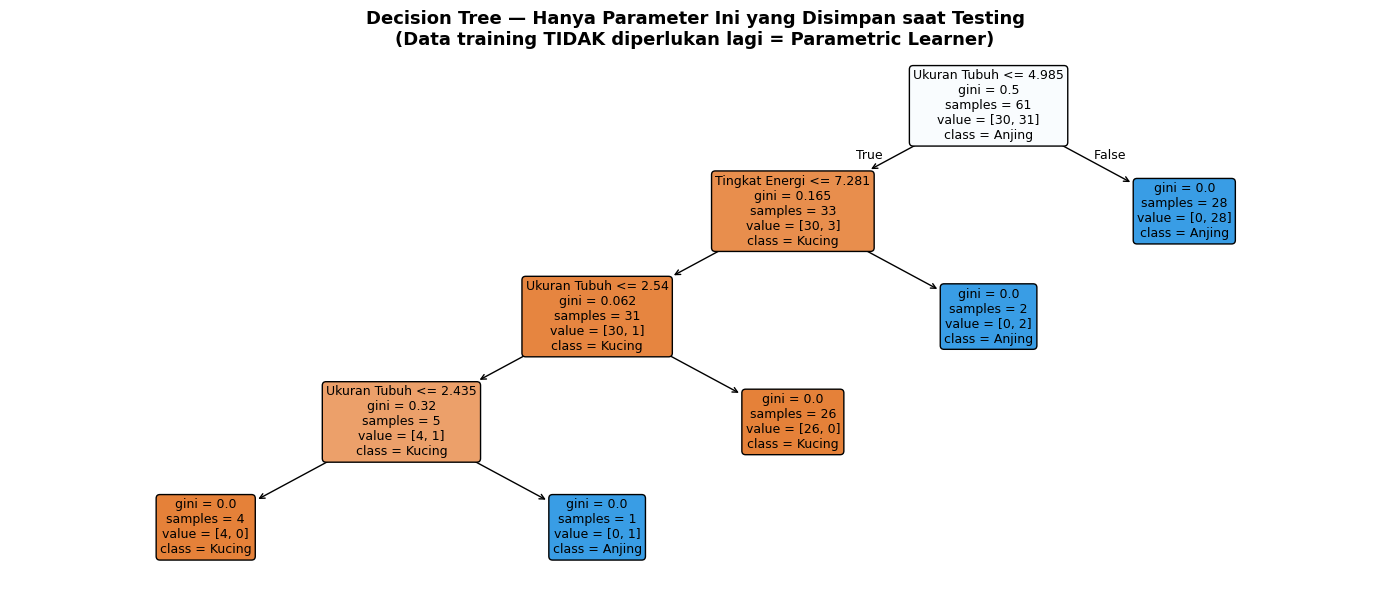

✅ Decision Tree: 9 node parameter.
   KNN harus simpan SEMUA 61 data training!


In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))
plot_tree(dt_model,
          feature_names=['Ukuran Tubuh', 'Tingkat Energi'],
          class_names=['Kucing', 'Anjing'],
          filled=True, rounded=True, ax=ax, fontsize=9)
ax.set_title('Decision Tree — Hanya Parameter Ini yang Disimpan saat Testing\n'
             '(Data training TIDAK diperlukan lagi = Parametric Learner)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{save_folder}/decision_tree_no3.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Decision Tree: {dt_model.tree_.node_count} node parameter.')
print(f'   KNN harus simpan SEMUA {len(y)} data training!')

8. SIMPAN PERBANDINGAN MEMORI KE EXCEL

In [ ]:
df_memori = pd.DataFrame({
    'Jumlah_Data_Training' : sizes,
    'Memori_KNN_bytes'     : knn_mem_list,
    'Memori_KNN_KB'        : [round(m/1024, 2) for m in knn_mem_list],
    'Memori_DT_bytes'      : dt_mem_list,
    'Memori_DT_KB'         : [round(m/1024, 2) for m in dt_mem_list],
    'Rasio_KNN_vs_DT'      : [round(k/d, 1) for k,d in zip(knn_mem_list, dt_mem_list)]
})

df_kesimpulan = pd.DataFrame({
    'Aspek'             : ['Tipe Learner', 'Yang Disimpan',
                           'Skala Memori', 'Komputasi/Prediksi',
                           'Data Setelah Training'],
    'KNN'               : ['Non-Parametric', 'Seluruh data training',
                           'Linear', 'Hitung jarak ke semua data',
                           'WAJIB disimpan'],
    'Decision_Tree'     : ['Parametric', 'Hanya parameter pohon',
                           'Logaritmik', 'Ikuti cabang pohon',
                           'Bisa dibuang']
})

excel_path2 = f'{save_folder}/KNN_Memori_No3.xlsx'
with pd.ExcelWriter(excel_path2, engine='openpyxl') as writer:
    df_memori.to_excel(writer,     sheet_name='Perbandingan_Memori', index=False)
    df_kesimpulan.to_excel(writer, sheet_name='Kesimpulan',          index=False)

print(f'✅ Excel Memori disimpan!')
print(f'📄 {excel_path2}')
print(df_memori.to_string(index=False))

✅ Excel Memori disimpan!
📄 /content/drive/MyDrive/Tugas2No3/KNN_Simulation/KNN_Memori_No3.xlsx
 Jumlah_Data_Training  Memori_KNN_bytes  Memori_KNN_KB  Memori_DT_bytes  Memori_DT_KB  Rasio_KNN_vs_DT
                   50               800           0.78             2257          2.20              0.4
                  100              1600           1.56             2657          2.59              0.6
                  500              8000           7.81             3586          3.50              2.2
                 1000             16000          15.62             3986          3.89              4.0
                 5000             80000          78.12             4915          4.80             16.3
                10000            160000         156.25             5315          5.19             30.1
                50000            800000         781.25             6243          6.10            128.1
               100000           1600000        1562.50             6643          

In [ ]:
from google.colab import files

files.download(excel_path)   # KNN_Dataset.xlsx
files.download(excel_path2)  # KNN_Memori_No3.xlsx

print('✅ Semua file berhasil didownload!')
print('   📄 KNN_Dataset.xlsx')
print('   📄 KNN_Memori_No3.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Semua file berhasil didownload!
   📄 KNN_Dataset.xlsx
   📄 KNN_Memori_No3.xlsx


1. KNN = Non-Parametric Learner

KNN disebut Non-Parametric Learner karena tidak ada parameter numerik yang merangkum hasil pembelajaran. Tidak ada rumus, tidak ada bobot, tidak ada ringkasan apapun yang mewakili pola dari data training.

> Data training ITU SENDIRI adalah modelnya.

Artinya, saat proses testing, KNN wajib menyimpan seluruh data training di memori karena cara kerjanya adalah:

1. Ambil data uji baru
2. Hitung jarak ke SEMUA data training
3. Temukan K tetangga terdekat
4. Voting → tentukan label

Kalau data training dibuang, KNN tidak bisa bekerja sama sekali.

2. Decision Tree = Parametric Learner

Decision Tree sebaliknya adalah Parametric Learner,Setelah proses training selesai, semua pengetahuan dari data training dipadatkan menjadi parameter pohon berupa rangkaian kondisi if-then.

Saat testing, Decision Tree hanya perlu:
1. Baca fitur data uji
2. Ikuti cabang pohon dari root ke leaf
3. Output label di leaf node

Data training asli sudah tidak dibutuhkan lagi dan bisa dibuang setelah training selesai.

 3. Perbandingan Langsung

| Aspek | KNN (Non-Parametric) | Decision Tree (Parametric) |
|---|---|---|
| Yang disimpan saat testing | Seluruh data training | Hanya parameter pohon |
| Skala memori | Linear — makin banyak data makin besar memori | Logaritmik — hampir konstan |
| Komputasi per prediksi | Hitung jarak ke semua data | Ikuti cabang pohon |
| Data training setelah training | Wajib disimpan | Bisa dibuang |
| Contoh dataset 61 sampel | ~976 bytes | ~280 bytes (~3.5x lebih hemat) |
| Contoh dataset 100.000 sampel | ~1.562 KB | ~6.6 KB (~236x lebih hemat) |

4. Analogi Sederhana

Bayangkan kamu belajar mengenali hewan:

KNN = kamu membawa seluruh album foto semua hewan yang pernah kamu lihat ke mana-mana. Setiap kali melihat hewan baru, kamu buka semua foto dan cari yang paling mirip.

- Decision Tree = kamu membuat catatan kecil berisi aturan: *"Kalau ukurannya kecil dan energinya rendah → kucing. Kalau besar dan aktif → anjing."* Album foto asli sudah tidak perlu dibawa.

5. Kesimpulan

Semakin besar dataset, gap memori antara KNN dan Decision Tree semakin besar karena:

- KNN tumbuh linear → 2x lebih banyak data = 2x lebih banyak memori
- Decision Tree tumbuh logaritmik → 2x lebih banyak data hanya menambah sedikit node

Inilah konsekuensi utama dari sifat Non-Parametric: KNN tidak bisa "melupakan" data training karena tidak pernah benar-benar "belajar" dalam bentuk parameter — ia hanya mengingat semua contoh yang pernah dilihat.